In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import SimpleRNN, Dense, LSTM, GRU, Dropout, Input, LayerNormalization, MultiHeadAttention, Flatten
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Electric_Production.csv')
print(df.head())

         DATE    Value
0  01-01-1985  72.5052
1  02-01-1985  70.6720
2  03-01-1985  62.4502
3  04-01-1985  57.4714
4  05-01-1985  55.3151


In [3]:
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values(by='DATE')
data = df['Value'].values.reshape(-1,1)

In [4]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [5]:
def create_dataset(data, time_step=5):
    X, Y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])
        Y.append(data[i+time_step, 0])
    return np.array(X), np.array(Y)

time_step = 5
X, y = create_dataset(data_scaled, time_step)

In [6]:
X = X.reshape(X.shape[0], X.shape[1], 1)

In [7]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [8]:
model_rnn = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(time_step,1)),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mse')

history_rnn = model_rnn.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test))


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.1123 - val_loss: 0.0457
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0281 - val_loss: 0.0300
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0222 - val_loss: 0.0271
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0182 - val_loss: 0.0186
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0139 - val_loss: 0.0151
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0130 - val_loss: 0.0154
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0116 - val_loss: 0.0112
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0102 - val_loss: 0.0105
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0096 - val_loss: 0.0073
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0090 - val_loss: 0.0068
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0075 - val_loss: 0.0049
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0065 - val_loss: 0.0044

In [9]:
model_lstm = Sequential([
    LSTM(50, activation='relu', return_sequences=True, input_shape=(time_step,1)),
    Dropout(0.2),
    LSTM(50, activation='relu'),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

history_lstm = model_lstm.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test))

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.1879 - val_loss: 0.3402
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1367 - val_loss: 0.2347
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0730 - val_loss: 0.0882
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0299 - val_loss: 0.0194
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0292 - val_loss: 0.0371
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0258 - val_loss: 0.0350
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0213 - val_loss: 0.0235
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0196 - val_loss: 0.0279
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0180 - val_loss: 0.0223
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0181 - val_loss: 0.0284
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0190 - val_loss: 0.0220
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0

In [10]:
model_gru = Sequential([
    GRU(50, activation='relu', return_sequences=True, input_shape=(time_step,1)),
    Dropout(0.2),
    GRU(50, activation='relu'),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

model_gru.compile(optimizer='adam', loss='mse')

history_gru = model_gru.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test))


Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.1611 - val_loss: 0.2244
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0657 - val_loss: 0.0610
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0292 - val_loss: 0.0192
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0267 - val_loss: 0.0379
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0234 - val_loss: 0.0371
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0218 - val_loss: 0.0249
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0194 - val_loss: 0.0282
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0177 - val_loss: 0.0222
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0192 - val_loss: 0.0229
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0171 - val_loss: 0.0214
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0170 - val_loss: 0.0245
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0

In [11]:
def build_vit():
    inputs = Input(shape=(time_step, 1))

    x = LayerNormalization()(inputs)
    x = MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(1)(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

model_vit = build_vit()
model_vit.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.2023 - val_loss: 0.4062
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1943 - val_loss: 0.3939
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1865 - val_loss: 0.3819
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1792 - val_loss: 0.3702
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1719 - val_loss: 0.3588
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1650 - val_loss: 0.3477
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1584 - val_loss: 0.3370
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1519 - val_loss: 0.3267
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1459 - val_loss: 0.3166
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1400 - val_loss: 0.3068
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1343 - val_loss: 0.2973
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1290 - val_l

In [12]:
def predict_future(model, last_data, steps=10):
    future = []
    temp_input = last_data.flatten().tolist()

    for i in range(steps):
        x_input = np.array(temp_input[-time_step:])
        x_input = x_input.reshape(1, time_step, 1)

        yhat = model.predict(x_input, verbose=0)
        temp_input.append(yhat[0][0])
        future.append(yhat[0][0])

    return scaler.inverse_transform(np.array(future).reshape(-1,1))


In [13]:
future_rnn = predict_future(model_rnn, X_test[-1])
future_lstm = predict_future(model_lstm, X_test[-1])
future_gru = predict_future(model_gru, X_test[-1])
future_vit = predict_future(model_vit, X_test[-1])

future_dates = pd.date_range(
    start=df['DATE'].iloc[-1],
    periods=10,
    freq='Y'
)

/tmp/ipykernel_22163/2075991042.py:6: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  future_dates = pd.date_range(


In [15]:
result = pd.DataFrame({
    'Year': future_dates,
    'RNN': future_rnn.flatten(),
    'LSTM': future_lstm.flatten(),
    'GRU': future_gru.flatten(),
    'ViT': future_vit.flatten()
})

print(result)

        Year         RNN       LSTM        GRU        ViT
0 2018-12-31  103.610222  99.502556  95.998711  68.450424
1 2019-12-31  106.382225  97.316460  94.730576  68.450424
2 2020-12-31  101.493248  94.992584  93.647064  68.450424
3 2021-12-31   94.155083  94.215828  92.976875  68.450424
4 2022-12-31   90.414917  94.916389  92.859566  68.450424
5 2023-12-31   93.692619  94.837654  92.394432  68.450424
6 2024-12-31   99.711395  93.949432  92.023865  68.450424
7 2025-12-31  101.444084  93.304283  91.730515  68.450424
8 2026-12-31   97.235512  93.084679  91.509209  68.450424
9 2027-12-31   90.803162  93.068695  91.346214  68.450424


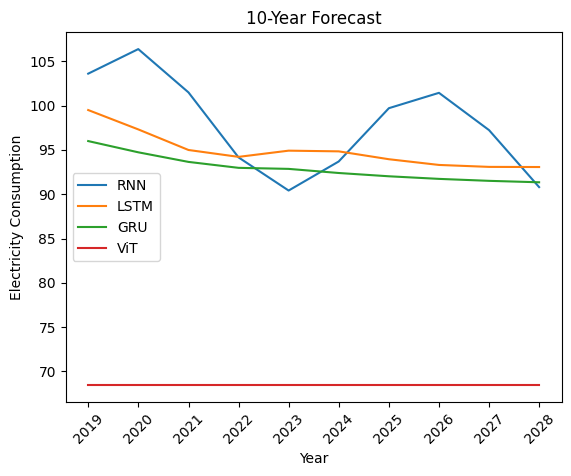

In [16]:
plt.plot(result['Year'], result['RNN'], label='RNN')
plt.plot(result['Year'], result['LSTM'], label='LSTM')
plt.plot(result['Year'], result['GRU'], label='GRU')
plt.plot(result['Year'], result['ViT'], label='ViT')

plt.xlabel("Year")
plt.ylabel("Electricity Consumption")
plt.title("10-Year Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.show()